# Feature Pipeline Step-by-Step Evaluation

This notebook walks through one full pass of the FoehnCast feature pipeline for a single configured spot and an isolated review dataset.
The notebook is only the inspection surface; the components under review are the same configuration, ingest, engineering, validation, storage, and Feast paths used by the project.

It follows the same operational path used by the project: select a spot, review the storage contract and Feast boundary, fetch forecast data, engineer curated features, validate them, store them through the active backend, and prepare the resulting data for Feast offline use.

The walkthrough uses a separate `notebook_eval` review dataset so the exercise stays isolated from the default `train` dataset.
This notebook is a one-off design-validation document that can later be distilled into README and GitHub Pages content.

## Table of Contents

1. Review Scope, Pipeline Configuration, and Feast Boundary
2. Storage and Terraform Review
3. Ingest Raw Forecast Rows
4. Engineer Curated Features
5. Validate Curated Features
6. Store Curated Rows Through the Active Backend
7. Build the Feast Offline Frame
8. Export a Feast-Ready Parquet File
9. Documentation Handoff and Next Steps

## Pipeline Review Flow

```text
[Configured spot + isolated review dataset]
                |
                v
[Review config: spot metadata, API, storage, Feast repo, export path]
                |
                v
[Review storage contract: local store, Feast overlay, Terraform cloud path]
                |
                v
[Fetch raw forecast rows for the selected coordinates]
                |
                v
[Engineer curated feature frame]
                |
                v
[Validate schema, completeness, and ranges]
                |
                v
[Write curated rows via local / S3 / BigQuery backend]
                |
                +------------------------------+
                |                              |
                v                              v
[Build Feast offline frame]        [Inspect stored dataset state]
                |
                v
[Export Feast-ready parquet artifact]
```

The review starts by selecting one configured spot and one isolated review dataset name.
It then checks the real configuration values that shape the rest of the walkthrough: spot metadata, API settings, storage backend, Feast repo/config surfaces, and the planned Feast export destination.

Before ingest begins, the notebook reviews how the local filesystem store, the optional Feast layer, and the Terraform-managed cloud path fit together.
That keeps the storage and feature-serving discussion explicit instead of burying it inside later steps.

Once the configuration, storage, and Feast contract are fixed, the notebook fetches raw forecast rows for the selected coordinates.
Those rows are then transformed into the curated feature frame used by the project, validated against the configured schema and ranges, written through the active storage adapter, and finally exported into the Feast offline format used for historical retrieval.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from foehncast import config as config_module
from foehncast.config import get_api_config, get_spots, get_storage_config
from foehncast.feature_pipeline.engineer import engineer_features
from foehncast.feature_pipeline.feast import (
    build_entity_rows,
    build_offline_store_frame,
    export_offline_store,
)
from foehncast.feature_pipeline.ingest import fetch_forecast
from foehncast.feature_pipeline.store import (
    list_datasets,
    read_features,
    write_features,
)
from foehncast.feature_pipeline.validate import run_validation

pd.set_option("display.max_columns", 50)

In [14]:
import base64
from IPython.display import Markdown, SVG
import requests


def render_mermaid(diagram: str, title: str | None = None) -> None:
    source = diagram.strip()
    encoded = base64.urlsafe_b64encode(source.encode("utf-8")).decode("ascii")
    endpoints = [
        ("GET", f"https://mermaid.ink/svg/{encoded}"),
        ("POST", "https://kroki.io/mermaid/svg"),
    ]
    last_error = None

    for method, url in endpoints:
        try:
            if method == "GET":
                response = requests.get(url, timeout=20)
            else:
                response = requests.post(url, data=source.encode("utf-8"), timeout=20)
            response.raise_for_status()
            if title:
                display(Markdown(f"### {title}"))
            display(SVG(data=response.text))
            return
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        "Could not render Mermaid from the notebook kernel. "
        "Check network access to mermaid.ink or kroki.io."
    ) from last_error


print("Mermaid renderer ready. Run a component-diagram cell to render it.")

Mermaid renderer ready. Run a component-diagram cell to render it.


## 1. Review Scope, Pipeline Configuration, and Feast Boundary

This step fixes the review scope without touching the default training dataset.
It validates the real configuration contract for the selected spot, API settings, storage backend, Feast hand-off, and isolated review dataset.

### Step 1 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 1 Component Diagram

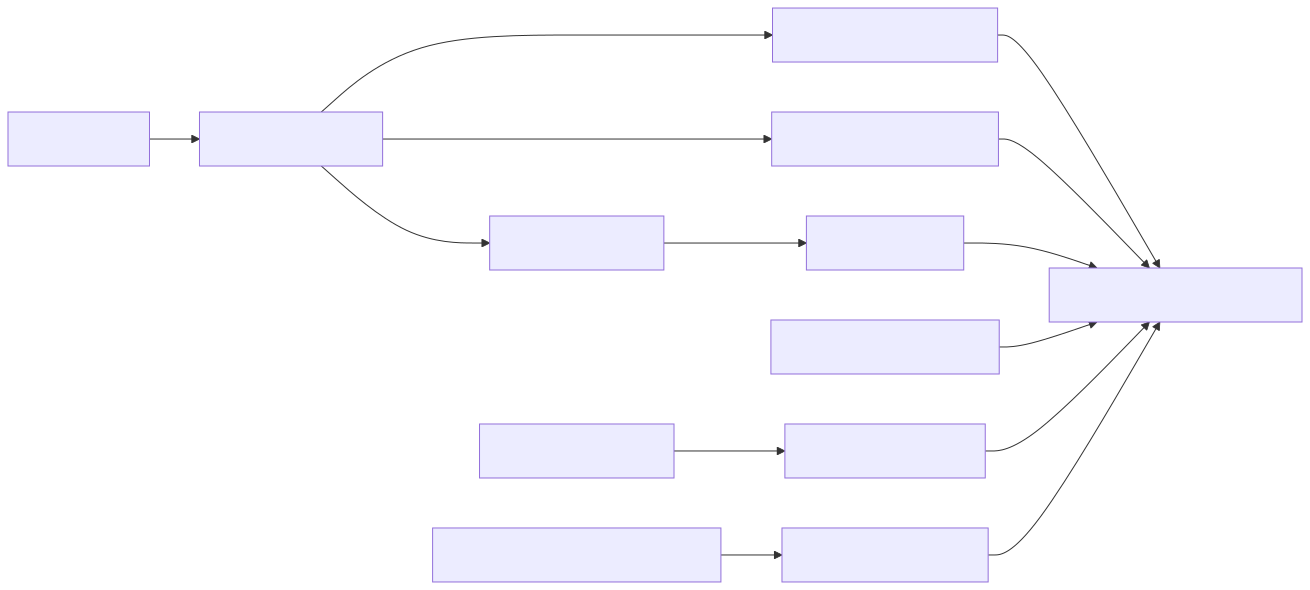

In [26]:
render_mermaid(
    """
    flowchart LR
        A[config.yaml] --> B[config.py loaders]
        B --> C[spot definitions]
        B --> D[Open-Meteo API config]
        B --> E[storage backend config]
        F[feature_store.yaml] --> G[Feast local contract]
        H[feature_store.gcp.yaml.example] --> I[Feast cloud contract]
        C --> J[selected spot]
        D --> K[reviewed pipeline contract]
        E --> K
        J --> K
        L[isolated review dataset] --> K
        G --> K
        I --> K
    """,
    title="Step 1 Component Diagram",
)

In [30]:
import yaml

for _obsolete_name in ("local_file", "cloud_file", "stale_name"):
    globals().pop(_obsolete_name, None)
globals().pop("_obsolete_name", None)

spots = {spot["id"]: spot for spot in get_spots()}
spot_overview = pd.DataFrame(get_spots())[
    [
        "id",
        "name",
        "canton",
        "lat",
        "lon",
        "shore_orientation_deg",
        "ideal_wind_dir_min",
        "ideal_wind_dir_max",
    ]
]
spot_id = "silvaplana"
dataset = "notebook_eval"

if spot_id not in spots:
    raise KeyError(f"Unknown spot_id {spot_id!r}. Choose one of: {sorted(spots)}")

spot = spots[spot_id]
api_cfg = get_api_config()["open_meteo"]
storage_cfg = get_storage_config()
project_root = Path(config_module.__file__).resolve().parents[2]
feast_repo_path = project_root / "feature_repo"
feast_local_config_path = feast_repo_path / "feature_store.yaml"
feast_cloud_config_example_path = feast_repo_path / "feature_store.gcp.yaml.example"
feast_export_path = project_root / "data" / "feast" / f"{dataset}.parquet"

feast_local_cfg = yaml.safe_load(feast_local_config_path.read_text())
feast_cloud_cfg = yaml.safe_load(feast_cloud_config_example_path.read_text())

feast_contract_overview = pd.DataFrame(
    [
        {
            "surface": "provider",
            "local": feast_local_cfg["provider"],
            "cloud_example": feast_cloud_cfg["provider"],
        },
        {
            "surface": "offline_store",
            "local": feast_local_cfg["offline_store"]["type"],
            "cloud_example": feast_cloud_cfg["offline_store"]["type"],
        },
        {
            "surface": "online_store",
            "local": feast_local_cfg["online_store"]["type"],
            "cloud_example": feast_cloud_cfg["online_store"]["type"],
        },
        {
            "surface": "registry",
            "local": feast_local_cfg["registry"],
            "cloud_example": feast_cloud_cfg["registry"],
        },
    ]
)

display(spot_overview.set_index("id"))
display(feast_contract_overview.set_index("surface"))
print(f"Selected spot: {spot['name']} ({spot_id})")
print(f"Review dataset: {dataset}")
print(f"Shore orientation: {spot['shore_orientation_deg']} deg")
print(
    "Ideal wind window: "
    f"{spot['ideal_wind_dir_min']} -> {spot['ideal_wind_dir_max']} deg"
)
print(f"Storage backend: {storage_cfg['backend']}")
print(f"Forecast URL: {api_cfg['forecast_url']}")
print(f"Forecast horizon (days): {api_cfg['forecast_days']}")
print(f"Feast repo path: {feast_repo_path}")
print(f"Feast local config: {feast_local_config_path}")
print(f"Feast cloud example: {feast_cloud_config_example_path}")
print(f"Feast export path: {feast_export_path}")
print(
    "Feast hand-off: local exported parquet -> local file/SQLite repo; "
    "cloud curated BigQuery -> BigQuery/Datastore repo"
)
print(
    "Feast remains downstream of curated features and does not replace "
    "ingest, validation, or storage."
)

,name,canton,lat,lon,shore_orientation_deg,ideal_wind_dir_min,ideal_wind_dir_max
id,,,,,,,
silvaplana,Silvaplana,GR,46.45,9.79,225,180,270
urnersee,Urnersee,UR,46.93,8.60,180,150,210
neuchatel,Lac de Neuchatel,NE,46.85,6.85,270,200,310
bodensee,Bodensee,TG,47.63,9.37,180,180,300
walensee,Walensee,SG,47.12,9.22,270,220,320
thunersee,Thunersee,BE,46.72,7.72,270,220,330


,local,cloud_example
surface,,
provider,local,gcp
offline_store,file,bigquery
online_store,sqlite,datastore
registry,../data/feast/registry.db,gs://your-gcp-bucket/feast/registry.db


Selected spot: Silvaplana (silvaplana)
Review dataset: notebook_eval
Shore orientation: 225 deg
Ideal wind window: 180 -> 270 deg
Storage backend: local
Forecast URL: https://api.open-meteo.com/v1/forecast
Forecast horizon (days): 7
Feast repo path: /Users/jvr/github/HSLU/MLOPS/foehncast/feature_repo
Feast local config: /Users/jvr/github/HSLU/MLOPS/foehncast/feature_repo/feature_store.yaml
Feast cloud example: /Users/jvr/github/HSLU/MLOPS/foehncast/feature_repo/feature_store.gcp.yaml.example
Feast export path: /Users/jvr/github/HSLU/MLOPS/foehncast/data/feast/notebook_eval.parquet
Feast hand-off: local exported parquet -> local file/SQLite repo; cloud curated BigQuery -> BigQuery/Datastore repo
Feast remains downstream of curated features and does not replace ingest, validation, or storage.


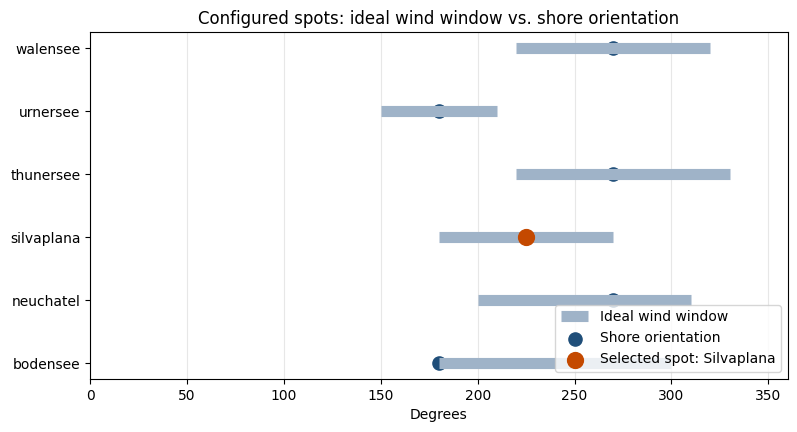

In [3]:
step1_plot_df = spot_overview.sort_values("id").reset_index(drop=True)
selected_y = int(step1_plot_df.index[step1_plot_df["id"] == spot_id][0])
selected_row = step1_plot_df.loc[selected_y]

fig, ax = plt.subplots(figsize=(9, 4.5))
y_positions = list(range(len(step1_plot_df)))

ax.hlines(
    y=y_positions,
    xmin=step1_plot_df["ideal_wind_dir_min"],
    xmax=step1_plot_df["ideal_wind_dir_max"],
    color="#9fb3c8",
    linewidth=8,
    label="Ideal wind window",
)
ax.scatter(
    step1_plot_df["shore_orientation_deg"],
    y_positions,
    color="#1f4e79",
    s=90,
    label="Shore orientation",
)
ax.scatter(
    [selected_row["shore_orientation_deg"]],
    [selected_y],
    color="#c44900",
    s=130,
    label=f"Selected spot: {selected_row['name']}",
    zorder=3,
)

ax.set_xlim(0, 360)
ax.set_xlabel("Degrees")
ax.set_yticks(y_positions, step1_plot_df["id"])
ax.set_title("Configured spots: ideal wind window vs. shore orientation")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")
plt.show()

### Step 1 Review Summary

This step is useful because it makes the configuration and Feast contract visible before any data is fetched or transformed.
The notebook is only the review surface; the real subjects under inspection are the configured spot metadata, the API contract, the storage contract, the Feast repo/config hand-off, and the isolated review dataset that keeps the exercise away from the default training split.
At this point in the notebook, we are not validating forecast quality yet; we are validating whether those real components are represented in a way that is sound for downstream computation and feature serving.

#### Current Configuration Type Review

| Field group | Current representation | Assessment | Recommendation |
| --- | --- | --- | --- |
| Spot identifiers and labels | Strings such as `id`, `name`, `canton`, `difficulty`, `water_type` | Reasonable and readable | Keep as strings, but consider enums for constrained fields such as `difficulty`, `water_type`, and `storage.backend` |
| Coordinates | `lat` and `lon` as decimal-degree floats | Correct for configuration and API calls | Keep as floats in config, validate latitude in `[-90, 90]` and longitude in `[-180, 180]` |
| Altitude and forecast horizon | Integers such as `altitude_m` and `forecast_days` | Sound and easy to validate | Keep as integers with explicit range checks |
| URLs and paths | Strings such as API URLs and storage paths | Acceptable, but semantically weak | Normalize to typed URL and Path values after loading config |
| Angular values | `shore_orientation_deg`, `ideal_wind_dir_min`, and `ideal_wind_dir_max` in degrees | Human-readable, but computationally fragile if treated as plain linear numbers | Keep degrees in YAML for readability, then normalize into a dedicated angular type in code |
| Direction ranges | Minimum and maximum degrees | Works for simple intervals, but breaks conceptually when a range crosses north, for example `330 -> 30` | Replace raw min/max logic with a dedicated direction-window representation |

#### Angle and Direction Review

Directional fields are circular quantities, not ordinary linear numbers.
That means values such as `359` degrees and `1` degree are close to each other, even though their numeric difference looks large if treated naively.
For this reason, direction ranges should not be handled as plain scalar intervals without normalization.

A better approach is:
- Keep angles in configuration as degrees because that is the most readable format for humans.
- Normalize every angle to a canonical range such as `[0, 360)` immediately after loading configuration.
- Represent directional windows in code as either a center direction plus half-width, or as a dedicated type that knows how to test membership across the `0/360` boundary.
- For feature engineering and similarity calculations, prefer circular math such as radians or unit vectors `(cos(theta), sin(theta))` rather than raw degree subtraction alone.

The existing `shore_alignment` feature already moves in the right direction because it uses cosine similarity, which is a circular formulation rather than a linear one.
If the project later needs richer directional reasoning, a small typed angle utility is a better fit than introducing a dataframe library choice such as Polars.

#### Configuration Loading Review

The current loader returns nested dictionaries loaded from YAML.
That is workable for a small project, but it leaves type normalization implicit and spreads validation responsibility across the codebase.
A stronger design would be to keep YAML as the authoring format and then load it into typed models for spots, storage, validation, API settings, and Feast boundary selection.

That typed normalization layer should:
- coerce numeric values once at load time;
- normalize angular fields once at load time;
- validate categorical fields against allowed values;
- convert paths and URLs into semantically appropriate Python types;
- expose a dedicated direction-window abstraction instead of raw min/max pairs.

#### Feast Boundary Review

Because Feast is an intended part of the project, it should be explicit in step 1 instead of appearing only as a late export detail.
The current repository already encodes two Feast operating modes: a lightweight local repo with file offline storage plus SQLite online storage, and a cloud-oriented configuration path with BigQuery offline storage plus Datastore and GCS support.

That is the right architectural split because:
- Feast consumes curated features instead of replacing the feature pipeline;
- local Feast stays lightweight for development and notebook-driven validation;
- cloud Feast can read curated BigQuery tables or views without changing the upstream ingest, engineering, validation, or storage stages;
- Airflow, MLflow, and Feast stay adjacent but distinct: Airflow refreshes features, MLflow tracks model artifacts, and Feast exposes stable feature retrieval downstream.

So step 1 should treat Feast as part of the reviewed contract:
- explicit repo and config surfaces;
- explicit local and cloud source modes;
- explicit separation between curated storage and feature serving.

#### Model Path And Preprocessing Review

The configured model path belongs in this step too because it shapes which downstream preprocessing choices are actually justified.
At the moment the training path is tree-based, so the main configuration priority is not a generic scaler.
It is preserving physically meaningful feature representations, especially for circular directions and denominator-sensitive wind-quality features.

That means the configuration and loading layer should prefer:
- explicit angular normalization and circular utilities;
- clear unit semantics at ingest and labeling boundaries;
- stable engineered-feature definitions over blanket feature scaling switches.

#### BigQuery and Location-Feature Review

Yes, location-specific features should be considered if BigQuery is going to serve as a serious analytical or offline feature backend.
The current BigQuery writer stores the curated feature frame together with `spot_id`, `dataset_name`, and `forecast_time`, which is a reasonable minimum, but it leaves BigQuery queries dependent on joining configuration knowledge back in elsewhere.

A stronger warehouse-oriented design would separate the data into:
- a fact table for time-varying forecast and engineered feature rows;
- a spot dimension table for static location metadata such as `lat`, `lon`, `altitude_m`, `canton`, `water_type`, `difficulty`, and directional definitions;
- optionally a denormalized analytical view that joins both for easy querying.

For BigQuery specifically, the most useful additions are:
- a native `GEOGRAPHY` point derived from longitude and latitude for spatial filtering and mapping;
- normalized angular columns, and possibly `sin` and `cos` forms for stable directional analytics;
- partitioning by forecast date or event timestamp and clustering by `spot_id` and `dataset_name`.

External tables are useful for raw or staged parquet data in GCS, especially if you want cheap landing zones or BigLake-style access without loading everything into native tables immediately.
They are less attractive as the main curated feature store because native BigQuery tables are usually easier to optimize, validate, join, and query repeatedly for training and monitoring.

The practical recommendation is: keep external tables for a raw or staging layer if needed, but keep the curated feature layer in native BigQuery tables or a native materialized representation.
That gives you reliable query performance while still allowing location-aware analysis through either a spot dimension table or a denormalized analytical view.

In descriptive terms, the question for this step is not only whether Silvaplana is a plausible selected spot.
It is also whether the configuration schema, Feast boundary, and warehouse representation give the later pipeline steps data in shapes that are safe, explicit, computationally appropriate, and query-friendly.

## 2. Storage, Terraform, and Feast Surface Review

This step validates the real storage responsibilities behind the feature pipeline: how curated features are stored locally, what Feast actually requires, how the cloud path is wired through Terraform, and where a raw landing layer should live.
The main point is that the raw landing layer, the curated feature store, and the Feast layer serve different purposes and should not be collapsed into one storage decision or one implementation surface.
Unlike step 1, the emphasis here is not just configuration values. It is whether the repository keeps those roles separated cleanly enough that the local workflow and the cloud target stay aligned.

#### Storage Roles

| Surface | Local baseline | Cloud direction | Why this is the best fit right now |
| --- | --- | --- | --- |
| Raw landing layer | Local files if retained at all | GCS object storage | Cheap, append-friendly, schema-flexible, and well suited to immutable raw payload capture |
| Main curated feature store | `LocalFeatureStoreBackend -> data/<dataset>/<spot>.parquet` | `BigQueryFeatureStoreBackend -> <project>.<dataset>.<table>` | Mirrors the current adapter split in `feature_pipeline.store` |
| Feast offline source | `export_offline_store -> data/feast/<dataset>.parquet` | BigQuery table or view over curated rows | Matches the current local Feast helper and the cloud Feast example |
| Feast registry | `data/feast/registry.db` via `feature_store.yaml` | GCS registry path via `feature_store.gcp.yaml.example` | Registry metadata stays separate from the main curated feature dataset |
| Feast online store | Local SQLite | Datastore | Optional online lookup path only |
| S3-compatible object storage | Optional experiment path via `S3FeatureStoreBackend` | Not the primary target | Useful only if we deliberately want object-store compatibility tests; it is not the simplest baseline |

#### S3 vs Local File Baseline

Using S3-compatible storage locally can look more elegant because it resembles cloud object storage, but in this project it would add infrastructure without solving the main cloud alignment problem.
The main cloud curated store is already BigQuery, not object storage, and the local Feast setup already works with exported parquet plus SQLite.

That means the real question is not whether local storage should look more like S3.
The real question is whether local defaults should stay simple while the cloud path stays analytically strong.
For the course and for day-to-day development, the best default is still:
- local raw and curated data stay file-based;
- local Feast stays file offline store plus SQLite online store;
- S3-compatible storage remains optional for explicit integration tests, not the default developer path.

#### Landing Layer

Yes, if the project wants a proper landing step, raw data should be kept separately from curated feature rows.
Best practice is to keep raw payloads immutable and cheap to store, then derive curated tables from them.

For this stack, the cleanest split is:
- raw landing in local files locally and GCS in the cloud;
- curated feature rows in parquet locally and native BigQuery tables in the cloud;
- Feast reading curated data only, never raw landed payloads.

#### Should Raw Landing Also Live In BigQuery?

Usually no, not as the primary landing format.
BigQuery is strongest when data is already shaped for analytical querying, partitioning, and repeated downstream consumption.
Raw API payloads are usually cheaper and more flexible in object storage, especially when schemas may drift or when you want to keep the original response unchanged.

If cloud analysis over raw data is needed, the better pattern is:
- store raw files in GCS;
- optionally expose them through external tables or a staging load;
- transform them into curated native BigQuery tables for analytics, training, and Feast offline use.

#### What Feast Can And Cannot Do

Feast should sit on the curated layer, not on the raw landing layer.
It is designed to expose stable feature definitions and consistent offline or online retrieval, not to act as a raw ingestion store or bronze-layer manager.

That means:
- Feast can read curated parquet locally;
- Feast can read curated BigQuery tables or views in the cloud;
- Feast should not be responsible for raw landing retention, raw schema drift, or ingestion orchestration.

#### Course-Aligned Best Practice

The course direction favors local-first reproducibility, clear pipeline boundaries, and avoiding unnecessary platform complexity.
In that framing, the most defensible design is:
- keep the local baseline simple and inspectable;
- use a distinct raw landing layer only when it serves a clear pipeline or audit purpose;
- use native BigQuery tables for the curated cloud feature layer;
- use GCS for raw landing, artifacts, Feast registry, and staging;
- keep Feast optional and layered on top of curated features rather than making it the center of the storage architecture.

#### Recommended Target Architecture

| Layer | Local recommendation | Cloud recommendation |
| --- | --- | --- |
| Raw landing | Files | GCS |
| Curated features | Parquet | BigQuery native tables |
| Feast offline | Exported parquet | BigQuery table or view |
| Feast registry and staging | Local files | GCS |
| Feast online | SQLite | Datastore |

The next cells render this split and inspect the concrete storage and Terraform surfaces from the live repository.

#### Pandera Recommendation

Pandera is still optional.
It becomes worthwhile if the project formalizes a raw-to-curated contract with more explicit dataframe boundaries and wants reusable schema checks before writes to parquet, BigQuery, or Feast export inputs.
For the current stage, it is a good candidate for the curated storage boundary, but it is not required to make this architecture sound.

### Step 2 Component Diagram

Run the next cell to render the diagram from the notebook kernel, then inspect the concrete storage and Terraform surfaces in the following cell.

### Step 2 Component Diagram

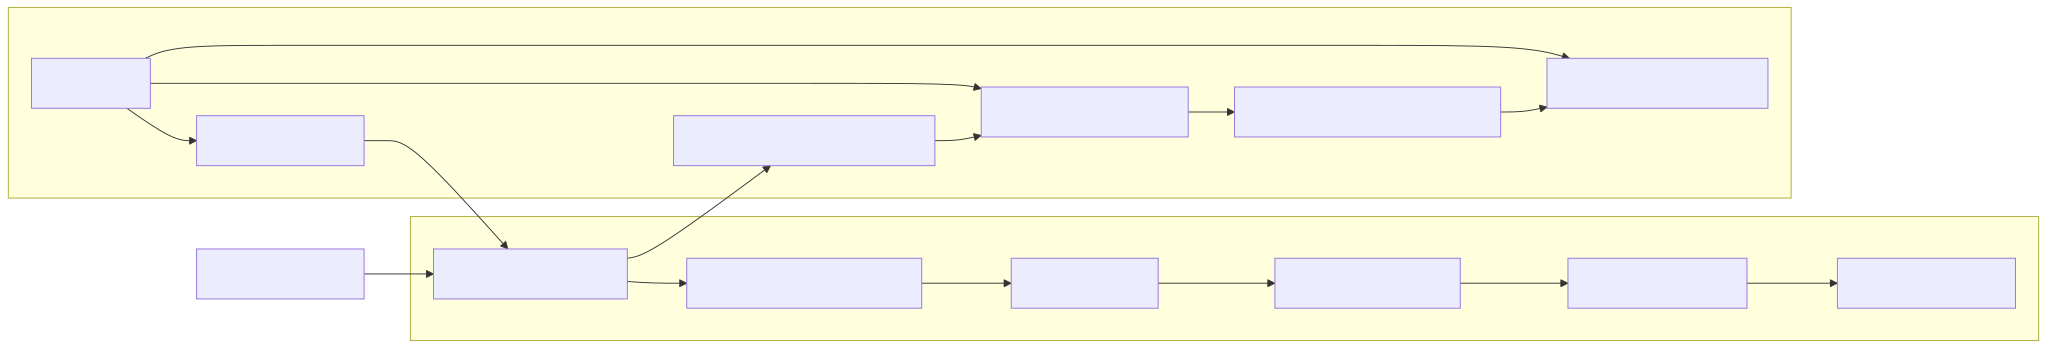

In [31]:
render_mermaid(
    """
    flowchart LR
        A[Raw landing files] --> B[Curated feature rows]
        C[GCS raw landing] --> B

        subgraph Local
            B --> D[LocalFeatureStoreBackend]
            D --> E[data/<dataset>/<spot>.parquet]
            E --> F[export_offline_store]
            F --> G[data/feast/<dataset>.parquet]
            G --> H[feature_store.yaml]
        end

        subgraph Cloud
            B --> I[BigQueryFeatureStoreBackend]
            I --> J[BigQuery curated table]
            J --> K[feature_store.gcp.yaml.example]
            L[Terraform] --> C
            L --> J
            L --> M[GCS registry and staging]
            K --> M
        end
    """,
    title="Step 2 Component Diagram",
)

In [32]:
gcp_cfg = config_module.get_gcp_config()
cloud_project = (
    storage_cfg.get("bigquery_project_id")
    or config_module.get_gcp_project_id()
    or "<gcp-project>"
)
cloud_dataset = storage_cfg.get("bigquery_dataset", "foehncast")
cloud_table = storage_cfg.get("bigquery_table", "forecast_features")
cloud_bigquery_target = f"{cloud_project}.{cloud_dataset}.{cloud_table}"
terraform_root = project_root / "terraform"
terraform_files = sorted(path.name for path in terraform_root.glob("*.tf"))

storage_surface_overview = pd.DataFrame(
    [
        {
            "surface": "runtime backend",
            "local_or_current": storage_cfg["backend"],
            "cloud_or_target": "local / s3 / bigquery",
            "implementation": "config.yaml -> storage.backend",
        },
        {
            "surface": "curated feature store",
            "local_or_current": (
                f"LocalFeatureStoreBackend -> {storage_cfg['local_path']}/{dataset}/{spot_id}.parquet"
            ),
            "cloud_or_target": (
                f"BigQueryFeatureStoreBackend -> {cloud_bigquery_target}"
            ),
            "implementation": "feature_pipeline.store adapters",
        },
        {
            "surface": "Feast offline source",
            "local_or_current": (
                f"export_offline_store -> {feast_export_path.relative_to(project_root)}"
            ),
            "cloud_or_target": f"BigQuery offline store -> {cloud_bigquery_target}",
            "implementation": "feature_pipeline.feast + feature_repo config",
        },
        {
            "surface": "Feast registry",
            "local_or_current": feast_local_cfg["registry"],
            "cloud_or_target": feast_cloud_cfg["registry"],
            "implementation": "feature_store.yaml variants",
        },
        {
            "surface": "Feast online store",
            "local_or_current": feast_local_cfg["online_store"]["type"],
            "cloud_or_target": feast_cloud_cfg["online_store"]["type"],
            "implementation": "feature_store.yaml variants",
        },
        {
            "surface": "raw landing direction",
            "local_or_current": "local files only if retained",
            "cloud_or_target": gcp_cfg.get("bucket_name") or "GCS object storage",
            "implementation": "storage review target, not Feast",
        },
    ]
)
terraform_surface_overview = pd.DataFrame({"terraform_file": terraform_files})

display(storage_surface_overview.set_index("surface"))
display(terraform_surface_overview)
print(f"Active runtime backend: {storage_cfg['backend']}")
print(f"Cloud curated target: {cloud_bigquery_target}")
print(
    "Boundary reminder: curated rows live in the main store first; Feast reads "
    "a local exported parquet artifact or a curated BigQuery table/view downstream."
)

,local_or_current,cloud_or_target,implementation
surface,,,
runtime backend,local,local / s3 / bigquery,config.yaml -> storage.backend
curated feature store,LocalFeatureStoreBackend -> data/notebook_eval...,BigQueryFeatureStoreBackend -> your-gcp-projec...,feature_pipeline.store adapters
Feast offline source,export_offline_store -> data/feast/notebook_ev...,BigQuery offline store -> your-gcp-project.foe...,feature_pipeline.feast + feature_repo config
Feast registry,../data/feast/registry.db,gs://your-gcp-bucket/feast/registry.db,feature_store.yaml variants
Feast online store,sqlite,datastore,feature_store.yaml variants
raw landing direction,local files only if retained,foehncast-data,"storage review target, not Feast"


,terraform_file
0,main.tf
1,outputs.tf
2,providers.tf
3,variables.tf


Active runtime backend: local
Cloud curated target: your-gcp-project.foehncast.forecast_features
Boundary reminder: curated rows live in the main store first; Feast reads a local exported parquet artifact or a curated BigQuery table/view downstream.


## 3. Ingest Raw Forecast Rows

This stage exercises the live ingest path for one configured spot and shows the raw forecast shape,
time range, and column coverage before any engineering, curated storage, or Feast shaping happens.

### Step 3 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 3 Component Diagram

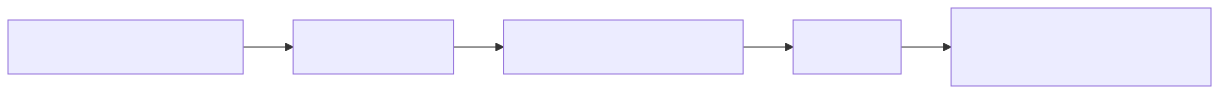

In [19]:
render_mermaid(
    """
    flowchart LR
        A[Selected spot lat and lon] --> B[fetch_forecast]
        B --> C[Open-Meteo forecast API]
        C --> D[raw_df]
        D --> E[Column and timestamp checks]
    """,
    title="Step 3 Component Diagram",
)

In [4]:
raw_df = fetch_forecast(spot["lat"], spot["lon"])

expected_columns = [column.strip() for column in api_cfg["hourly_params"].split(",")]
missing_columns = sorted(set(expected_columns) - set(raw_df.columns))
unexpected_columns = sorted(set(raw_df.columns) - set(expected_columns))
index_timezone = str(raw_df.index.tz) if raw_df.index.tz is not None else "naive"

ingest_checks = pd.DataFrame(
    [
        {
            "rows": raw_df.shape[0],
            "columns": raw_df.shape[1],
            "expected_columns": len(expected_columns),
            "missing_expected": len(missing_columns),
            "unexpected_columns": len(unexpected_columns),
            "index_timezone": index_timezone,
            "monotonic_index": raw_df.index.is_monotonic_increasing,
            "duplicate_timestamps": int(raw_df.index.duplicated().sum()),
            "total_null_values": int(raw_df.isna().sum().sum()),
        }
    ]
)

display(ingest_checks)
print(f"Time range: {raw_df.index.min()} -> {raw_df.index.max()}")
print(f"Columns ({len(raw_df.columns)}): {sorted(raw_df.columns.tolist())}")
print("Missing expected columns:", missing_columns or "none")
print("Unexpected columns:", unexpected_columns or "none")
display(raw_df.head())

,rows,columns,expected_columns,missing_expected,unexpected_columns,index_timezone,monotonic_index,duplicate_timestamps,total_null_values
0,168,13,13,0,0,Europe/Zurich,True,0,0


Time range: 2026-05-05 00:00:00+02:00 -> 2026-05-11 23:00:00+02:00
Columns (13): ['cape', 'cloud_cover', 'lifted_index', 'precipitation', 'pressure_msl', 'relative_humidity_2m', 'temperature_2m', 'wind_direction_10m', 'wind_direction_80m', 'wind_gusts_10m', 'wind_speed_10m', 'wind_speed_120m', 'wind_speed_80m']
Missing expected columns: none
Unexpected columns: none


,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_direction_10m,wind_direction_80m,wind_gusts_10m,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,pressure_msl,cape,lifted_index
time,,,,,,,,,,,,,
2026-05-05 00:00:00+02:00,23.0,30.4,31.0,256,251,36.4,5.8,0.0,75,75,1016.8,0.0,6.4
2026-05-05 01:00:00+02:00,20.7,27.4,28.3,253,251,36.4,5.4,0.0,73,81,1016.8,0.0,6.9
2026-05-05 02:00:00+02:00,19.4,25.5,26.4,260,254,31.3,5.1,0.0,70,44,1016.4,0.0,8.9
2026-05-05 03:00:00+02:00,13.8,19.4,20.5,261,255,29.5,4.9,0.0,69,25,1015.4,0.0,8.7
2026-05-05 04:00:00+02:00,8.7,14.0,15.5,253,247,19.4,4.6,0.0,72,17,1015.1,0.0,10.0


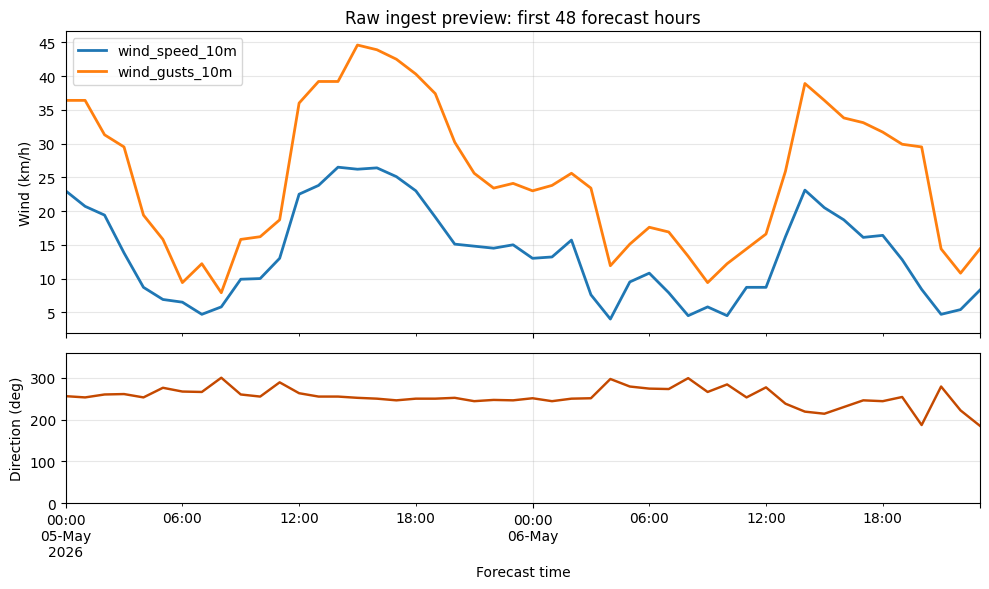

In [5]:
plot_df = raw_df[["wind_speed_10m", "wind_gusts_10m", "wind_direction_10m"]].head(48)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[2, 1])
plot_df[["wind_speed_10m", "wind_gusts_10m"]].plot(ax=axes[0], linewidth=2)
axes[0].set_ylabel("Wind (km/h)")
axes[0].set_title("Raw ingest preview: first 48 forecast hours")
axes[0].grid(alpha=0.3)

plot_df["wind_direction_10m"].plot(ax=axes[1], color="#c44900", linewidth=1.75)
axes[1].set_ylabel("Direction (deg)")
axes[1].set_ylim(0, 360)
axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Forecast time")

plt.tight_layout()
plt.show()

### Step 3 Review Summary

This step is sound if its purpose is to validate the upstream forecast contract before feature engineering begins.

- It exercises the same live Open-Meteo ingest helper the pipeline uses, so this review checks the real source path rather than a disconnected mock.
- The added contract checks make the important ingest assumptions visible: expected column coverage, timestamp ordering, duplicate timestamps, null counts, and whether the index is timezone-aware.
- Keeping the raw frame separate from spot metadata is reasonable at this stage because it preserves a clean distinction between upstream weather payloads and downstream enrichment.
- Feast is intentionally absent from this step: the ingest helper should stay focused on source-contract fidelity and timestamp semantics, leaving curated storage and feature serving to later stages.
- Timestamp semantics are now explicit at the ingest boundary: forecast and archive rows are localized to the configured API timezone before later storage and Feast hand-offs.

If the project adopts a formal raw landing layer, this step should preserve the upstream payload faithfully while keeping source-contract checks and timestamp semantics explicit.

## 4. Engineer Curated Features

This is the same transformation layer the batch feature pipeline uses before validation, storage, and Feast projection, so the review is checking the actual engineering contract rather than a notebook-only transformation.

### Step 4 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 4 Component Diagram

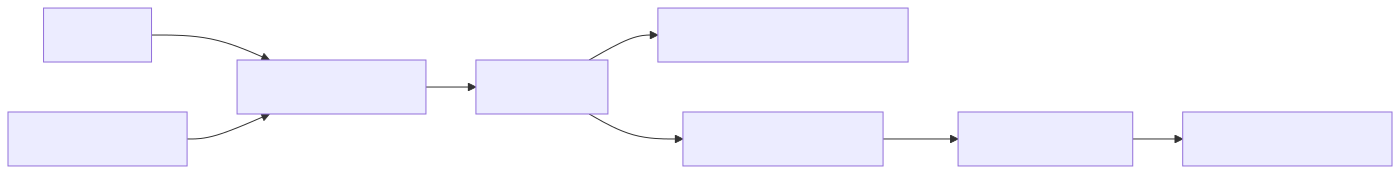

In [33]:
render_mermaid(
    """
    flowchart LR
        A[raw_df] --> B[engineer_features]
        C[shore orientation] --> B
        B --> D[feature_df]
        D --> E[Engineered feature checks]
        D --> F[Validation boundary]
        F --> G[Storage adapter]
        G --> H[Feast projection later]
    """,
    title="Step 4 Component Diagram",
)

In [34]:
feature_df = engineer_features(raw_df, spot["shore_orientation_deg"])
new_columns = sorted(set(feature_df.columns) - set(raw_df.columns))
preview_columns = new_columns + [
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
]
engineered_columns = [
    "hour_of_day_sin",
    "hour_of_day_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "wind_steadiness",
    "gust_factor",
    "shore_alignment",
]
preserved_raw_columns = sorted(set(raw_df.columns) - set(feature_df.columns))
index_timezone = (
    str(feature_df.index.tz) if feature_df.index.tz is not None else "naive"
)
feast_projection_ready = (
    isinstance(feature_df.index, pd.DatetimeIndex) or "time" in feature_df.columns
)

feature_checks = pd.DataFrame(
    [
        {
            "rows_match_raw": len(feature_df) == len(raw_df),
            "raw_columns_preserved": len(preserved_raw_columns) == 0,
            "preserves_datetime_index": isinstance(feature_df.index, pd.DatetimeIndex),
            "feast_projection_ready": feast_projection_ready,
            "engineered_column_count": len(new_columns),
            "all_expected_features_present": set(engineered_columns).issubset(
                feature_df.columns
            ),
            "nulls_in_engineered_features": int(
                feature_df[engineered_columns].isna().sum().sum()
            ),
            "shore_alignment_min": float(feature_df["shore_alignment"].min()),
            "shore_alignment_max": float(feature_df["shore_alignment"].max()),
            "gust_factor_min": float(feature_df["gust_factor"].min()),
            "gust_factor_max": float(feature_df["gust_factor"].max()),
        }
    ]
)

engineered_ranges = feature_df[engineered_columns].agg(["min", "max", "mean"]).T

display(feature_checks)
print(f"Engineered shape: {feature_df.shape}")
print(f"New feature columns ({len(new_columns)}): {new_columns}")
print(f"Missing raw columns after engineering: {preserved_raw_columns or 'none'}")
print(f"Feature index timezone: {index_timezone}")
print(
    "Feast hand-off readiness: "
    f"{'yes' if feast_projection_ready else 'no'}; engineering keeps the time basis but does not add serving metadata yet."
)
display(engineered_ranges)
display(feature_df[preview_columns].head())

,rows_match_raw,raw_columns_preserved,preserves_datetime_index,feast_projection_ready,engineered_column_count,all_expected_features_present,nulls_in_engineered_features,shore_alignment_min,shore_alignment_max,gust_factor_min,gust_factor_max
0,True,True,True,True,7,True,0,-0.990268,1.0,1.119048,7.25


Engineered shape: (168, 20)
New feature columns (7): ['day_of_year_cos', 'day_of_year_sin', 'gust_factor', 'hour_of_day_cos', 'hour_of_day_sin', 'shore_alignment', 'wind_steadiness']
Missing raw columns after engineering: none
Feature index timezone: Europe/Zurich
Feast hand-off readiness: yes; engineering keeps the time basis but does not add serving metadata yet.


,min,max,mean
hour_of_day_sin,-1.000000,1.000000,-2.643388e-17
hour_of_day_cos,-1.000000,1.000000,-5.815454e-17
day_of_year_sin,0.785650,0.845249,8.160542e-01
day_of_year_cos,-0.618671,-0.534373,-5.769495e-01
wind_steadiness,0.000000,0.729229,1.461155e-01
gust_factor,1.119048,7.250000,2.376082e+00
shore_alignment,-0.990268,1.000000,7.817504e-01


,day_of_year_cos,day_of_year_sin,gust_factor,hour_of_day_cos,hour_of_day_sin,shore_alignment,wind_steadiness,wind_speed_10m,wind_gusts_10m,wind_direction_10m
time,,,,,,,,,,
2026-05-05 00:00:00+02:00,-0.534373,0.845249,1.582609,1.000000,0.000000,0.857167,0.000000,23.0,36.4,256
2026-05-05 01:00:00+02:00,-0.534373,0.845249,1.758454,0.965926,0.258819,0.882948,0.052632,20.7,36.4,253
2026-05-05 02:00:00+02:00,-0.534373,0.845249,1.613402,0.866025,0.500000,0.819152,0.070767,19.4,31.3,260
2026-05-05 03:00:00+02:00,-0.534373,0.845249,2.137681,0.707107,0.707107,0.809017,0.166625,13.8,29.5,261
2026-05-05 04:00:00+02:00,-0.534373,0.845249,2.229885,0.500000,0.866025,0.882948,0.312877,8.7,19.4,253


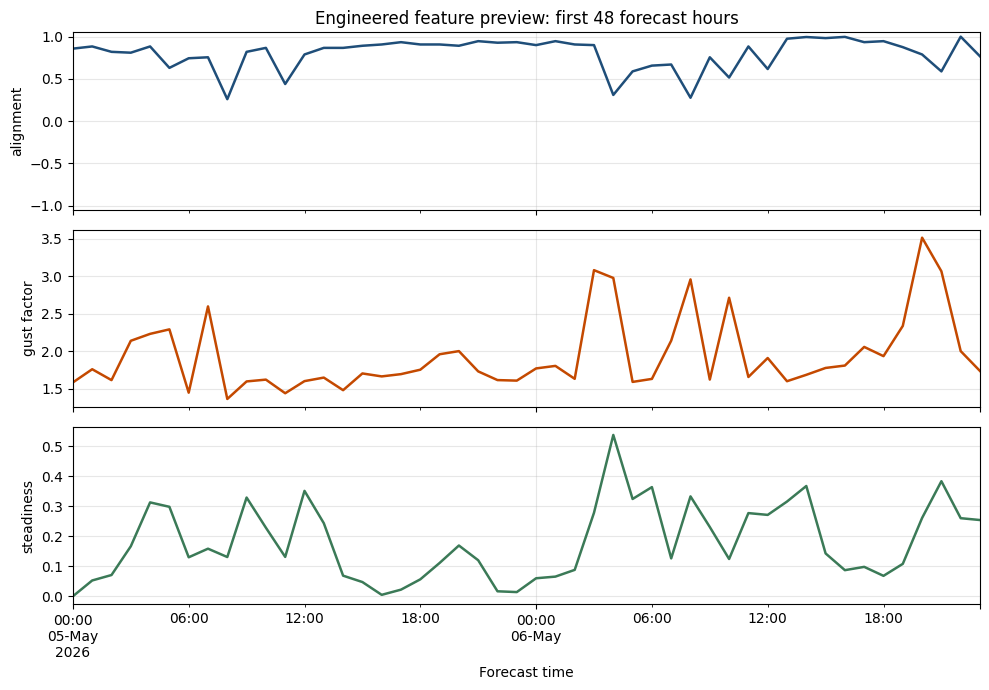

In [7]:
engineer_plot_df = feature_df[
    [
        "shore_alignment",
        "gust_factor",
        "wind_steadiness",
    ]
].head(48)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
engineer_plot_df["shore_alignment"].plot(ax=axes[0], color="#1f4e79", linewidth=1.8)
axes[0].set_ylabel("alignment")
axes[0].set_ylim(-1.05, 1.05)
axes[0].set_title("Engineered feature preview: first 48 forecast hours")
axes[0].grid(alpha=0.3)

engineer_plot_df["gust_factor"].plot(ax=axes[1], color="#c44900", linewidth=1.8)
axes[1].set_ylabel("gust factor")
axes[1].grid(alpha=0.3)

engineer_plot_df["wind_steadiness"].plot(ax=axes[2], color="#3b7a57", linewidth=1.8)
axes[2].set_ylabel("steadiness")
axes[2].set_xlabel("Forecast time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Step 4 Review Summary

This step is sound because it transforms raw forecast rows into compact signals that reflect time structure, wind consistency, gustiness, and directional suitability without mutating the upstream frame.

- The cyclical time features are appropriate because hour-of-day and day-of-year are circular variables that should not be represented as plain integers.
- `shore_alignment` is especially well aligned with the earlier configuration review: it already uses circular math through cosine similarity instead of naive angle subtraction.
- `gust_factor` and `wind_steadiness` are useful operational features, but they depend on denominator behavior and rolling-window assumptions, so it is important to keep their ranges visible in this review artifact and covered in tests.
- The engineering step preserves row count, preserves the raw forecast columns, and keeps the datetime index intact, which is the right contract for downstream validation, storage, and later Feast projection.
- Feast should still remain downstream from this step: engineering creates the curated feature frame, while storage and Feast helpers add the persistence and serving context later instead of polluting the feature definition here.
- The downstream label logic is now explicitly aligned with forecast units: raw wind speeds remain in the source weather units, while rule-based thresholds configured in knots are converted at scoring time instead of being compared naively.
- No additional global normalization is needed for the current training path because the model family is tree-based. The important downstream follow-up is feature representation quality, especially circular wind-direction handling and more stable gustiness signals, rather than a generic scaler.

The main remaining design question is not whether these features compute correctly in isolation.
It is whether the chosen engineered signals are complete enough for the ranking and quality prediction problem, or whether additional location-aware and weather-interaction features should later be added on top of this stable base.

## 5. Validate Curated Features

Validation covers schema, completeness, and configured numeric ranges. A failing result here is the
same signal that would stop the Airflow-managed feature refresh job.

### Step 5 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 5 Component Diagram

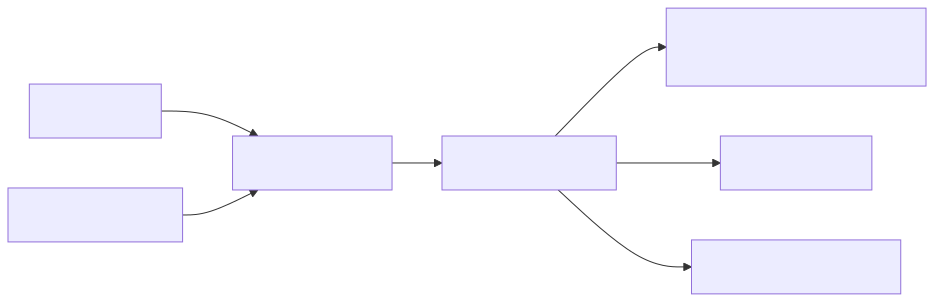

In [35]:
render_mermaid(
    """
    flowchart LR
        A[feature_df] --> B[run_validation]
        C[validation config] --> B
        B --> D[ValidationResult]
        D --> E[Schema, completeness, and range review]
        D --> F[Storage gate]
        D --> G[Feast projection gate]
    """,
    title="Step 5 Component Diagram",
)

In [36]:
validation_cfg = config_module.get_validation_config()
validation = run_validation(feature_df, spot_id)

required_columns = validation_cfg["required_columns"]
raw_columns = set(raw_df.columns)
engineered_validation_columns = [
    column for column in required_columns if column not in raw_columns
]
validated_columns = [
    column for column in required_columns if column in feature_df.columns
]
engineered_range_columns = [
    column
    for column in engineered_validation_columns
    if column in validation_cfg["ranges"] and column in feature_df.columns
]

summary = pd.DataFrame(
    [
        {
            "spot_id": validation.spot_id,
            "validated_columns": len(validated_columns),
            "engineered_columns_required": len(engineered_validation_columns),
            "engineered_range_checks": len(engineered_range_columns),
            "schema_valid": validation.schema_valid,
            "completeness_valid": validation.completeness_valid,
            "range_valid": validation.range_valid,
            "is_valid": validation.is_valid,
            "missing_columns": len(validation.missing_columns),
            "range_violations": len(validation.range_violations),
        }
    ]
)

null_summary = (
    pd.Series(validation.null_fractions, name="null_fraction")
    .sort_values(ascending=False)
    .rename_axis("column")
)

range_summary = pd.DataFrame(
    [
        {
            "column": column,
            "configured_min": bounds.get("min"),
            "observed_min": float(feature_df[column].min()),
            "observed_max": float(feature_df[column].max()),
            "configured_max": bounds.get("max"),
        }
        for column, bounds in validation_cfg["ranges"].items()
        if column in feature_df.columns
    ]
).set_index("column")

display(summary)
print(f"Required curated columns ({len(required_columns)}): {required_columns}")
print(f"Completeness threshold: {validation_cfg['completeness']['max_null_pct']}")
print(
    f"Engineered columns covered by range checks: {engineered_range_columns or 'none'}"
)
print("Missing columns:", validation.missing_columns or "none")
display(null_summary.head(10))
display(range_summary)

if validation.range_violations.empty:
    print("No range violations detected.")
else:
    display(validation.range_violations.head(20))

print(
    "Validation gate: ",
    "pass" if validation.is_valid else "fail",
    "-> downstream storage and Feast projection should only proceed on a valid curated frame.",
)

,spot_id,validated_columns,engineered_columns_required,engineered_range_checks,schema_valid,completeness_valid,range_valid,is_valid,missing_columns,range_violations
0,silvaplana,20,7,7,True,True,True,True,0,0


Required curated columns (20): ['wind_speed_10m', 'wind_speed_80m', 'wind_speed_120m', 'wind_direction_10m', 'wind_direction_80m', 'wind_gusts_10m', 'temperature_2m', 'precipitation', 'relative_humidity_2m', 'cloud_cover', 'pressure_msl', 'cape', 'lifted_index', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_year_sin', 'day_of_year_cos', 'wind_steadiness', 'gust_factor', 'shore_alignment']
Completeness threshold: 0.1
Engineered columns covered by range checks: ['hour_of_day_sin', 'hour_of_day_cos', 'day_of_year_sin', 'day_of_year_cos', 'wind_steadiness', 'gust_factor', 'shore_alignment']
Missing columns: none


column
wind_speed_10m     0.0
wind_speed_80m     0.0
gust_factor        0.0
wind_steadiness    0.0
day_of_year_cos    0.0
day_of_year_sin    0.0
hour_of_day_cos    0.0
hour_of_day_sin    0.0
lifted_index       0.0
cape               0.0
Name: null_fraction, dtype: float64

,configured_min,observed_min,observed_max,configured_max
column,,,,
wind_speed_10m,0,0.500000,26.500000,80.0
wind_speed_80m,0,0.500000,30.600000,80.0
wind_speed_120m,0,0.500000,31.200000,80.0
wind_gusts_10m,0,2.200000,67.700000,120.0
wind_direction_10m,0,8.000000,360.000000,360.0
wind_direction_80m,0,11.000000,333.000000,360.0
temperature_2m,-40,0.800000,9.500000,50.0
relative_humidity_2m,0,44.000000,100.000000,100.0
hour_of_day_sin,-1,-1.000000,1.000000,1.0


No range violations detected.
Validation gate:  pass -> downstream storage and Feast projection should only proceed on a valid curated frame.


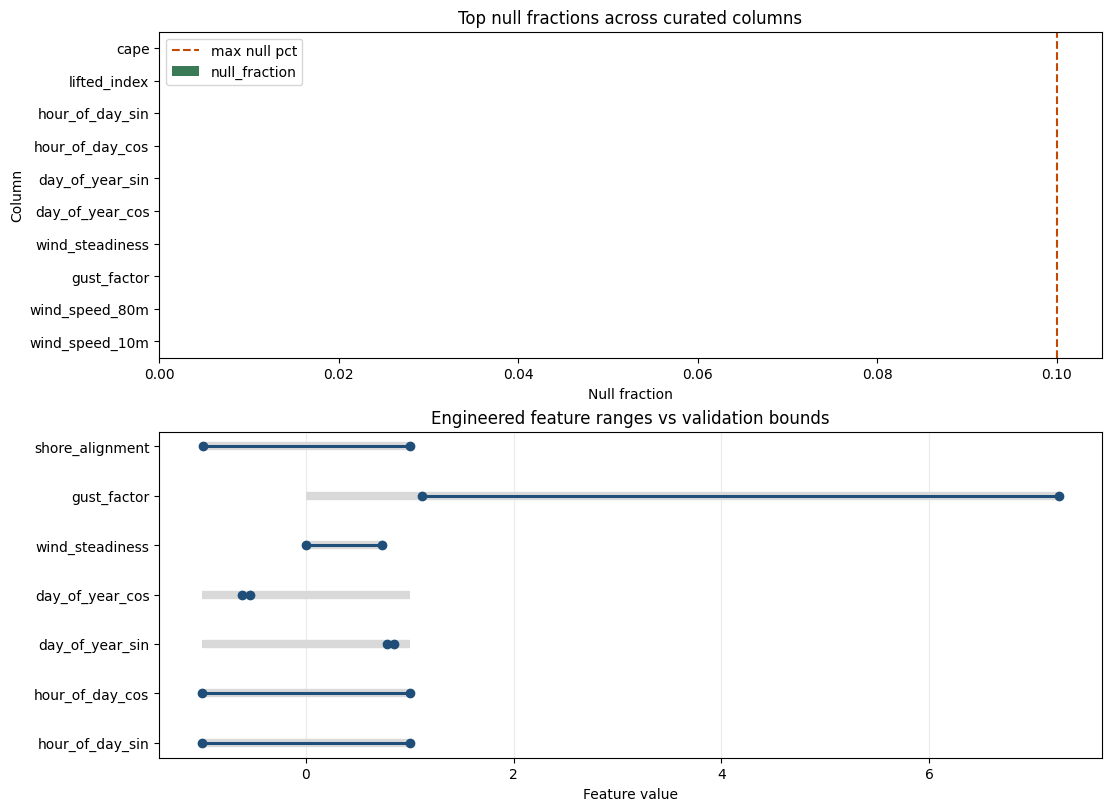

In [9]:
engineered_range_plot = range_summary.loc[
    [
        column
        for column in engineered_validation_columns
        if column in range_summary.index
    ]
]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

null_summary.head(10).sort_values().plot.barh(ax=axes[0], color="#3b7a57")
axes[0].axvline(
    validation_cfg["completeness"]["max_null_pct"],
    color="#c44900",
    linestyle="--",
    linewidth=1.5,
    label="max null pct",
)
axes[0].set_title("Top null fractions across curated columns")
axes[0].set_xlabel("Null fraction")
axes[0].set_ylabel("Column")
axes[0].legend()

for position, (column, row) in enumerate(engineered_range_plot.iterrows()):
    bound_min = (
        row["configured_min"]
        if pd.notna(row["configured_min"])
        else row["observed_min"]
    )
    bound_max = (
        row["configured_max"]
        if pd.notna(row["configured_max"])
        else row["observed_max"]
    )
    axes[1].hlines(position, bound_min, bound_max, color="#d9d9d9", linewidth=6)
    axes[1].plot(
        [row["observed_min"], row["observed_max"]],
        [position, position],
        color="#1f4e79",
        linewidth=2.2,
        marker="o",
    )

axes[1].set_yticks(range(len(engineered_range_plot)))
axes[1].set_yticklabels(engineered_range_plot.index)
axes[1].set_title("Engineered feature ranges vs validation bounds")
axes[1].set_xlabel("Feature value")
axes[1].grid(axis="x", alpha=0.25)

plt.show()

### Step 5 Review Summary

This step is sound only if validation is aligned with the actual curated feature frame, not just the raw ingest columns.

- The validator now checks the engineered columns that become part of the stored feature set, so step 5 matches both the documented review scope and the orchestration path.
- Cyclical encodings and `shore_alignment` are good candidates for explicit bounded checks because their valid domain is mathematically constrained to `[-1, 1]`.
- `wind_steadiness` and `gust_factor` are only lower-bounded at zero because large values can still represent real and important weather behavior rather than broken data.
- Completeness still matters at this stage because ratio-based engineered signals can become null when sustained wind approaches zero.
- Validation is the explicit gate before downstream persistence and Feast projection; a curated frame that fails here should not be written or exported further.
- This is also where the project proves that the configured validation schema actually covers the engineered feature surface rather than silently validating only the raw ingest subset.

This validation layer is still structural rather than semantic.
It can reject missing curated columns, null-heavy outputs, and impossible numeric values, but it does not yet decide whether a forecast is truly kiteable or whether feature interactions are good for one specific spot.

## 6. Store Curated Rows Through the Active Backend

This stage persists the validated feature rows and reads them back through the same storage adapter.
That keeps this review aligned with the repo's local, S3-compatible, or BigQuery-backed storage modes.

### Step 6 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 6 Component Diagram

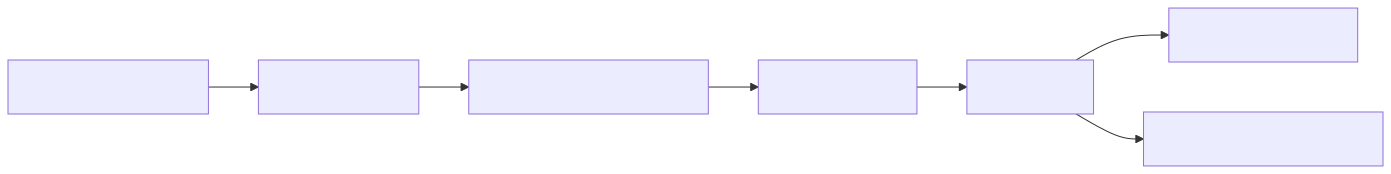

In [37]:
render_mermaid(
    """
    flowchart LR
        A[validated feature_df] --> B[write_features]
        B --> C[Storage backend adapter]
        C --> D[read_features]
        D --> E[stored_df]
        E --> F[Round-trip checks]
        E --> G[Feast-ready stored frame]
    """,
    title="Step 6 Component Diagram",
)

In [38]:
write_features(feature_df, spot_id=spot_id, dataset=dataset)
stored_df = read_features(spot_id=spot_id, dataset=dataset)

visible_datasets = list_datasets()
missing_after_roundtrip = sorted(set(feature_df.columns) - set(stored_df.columns))
extra_after_roundtrip = sorted(set(stored_df.columns) - set(feature_df.columns))
shared_columns = [
    column for column in feature_df.columns if column in stored_df.columns
]
numeric_shared_columns = (
    feature_df[shared_columns].select_dtypes(include="number").columns.tolist()
)

roundtrip_deltas = pd.Series(
    {
        column: float((stored_df[column] - feature_df[column]).abs().max())
        for column in numeric_shared_columns
    },
    name="max_abs_delta",
).sort_values(ascending=False)

original_index_tz = str(getattr(feature_df.index, "tz", None))
stored_index_tz = str(getattr(stored_df.index, "tz", None))
feast_roundtrip_ready = (
    isinstance(stored_df.index, pd.DatetimeIndex) or "time" in stored_df.columns
)
max_numeric_abs_delta = (
    float(roundtrip_deltas.max()) if not roundtrip_deltas.empty else 0.0
)
roundtrip_contract_valid = (
    validation.is_valid
    and not missing_after_roundtrip
    and not extra_after_roundtrip
    and list(stored_df.columns) == list(feature_df.columns)
    and feature_df.index.equals(stored_df.index)
    and original_index_tz == stored_index_tz
    and max_numeric_abs_delta == 0.0
)

roundtrip_summary = pd.DataFrame(
    [
        {
            "backend": storage_cfg["backend"],
            "validation_gate_passed": validation.is_valid,
            "rows_match_original": len(stored_df) == len(feature_df),
            "columns_match_original": list(stored_df.columns)
            == list(feature_df.columns),
            "missing_columns": len(missing_after_roundtrip),
            "extra_columns": len(extra_after_roundtrip),
            "index_equal": feature_df.index.equals(stored_df.index),
            "index_type": type(stored_df.index).__name__,
            "index_tz_matches": original_index_tz == stored_index_tz,
            "feast_roundtrip_ready": feast_roundtrip_ready,
            "roundtrip_contract_valid": roundtrip_contract_valid,
            "max_numeric_abs_delta": max_numeric_abs_delta,
            "datasets_visible": len(visible_datasets),
        }
    ]
)

display(roundtrip_summary)
print(f"Datasets visible through the storage adapter: {visible_datasets}")
print("Missing columns after read:", missing_after_roundtrip or "none")
print("Extra columns after read:", extra_after_roundtrip or "none")
print(f"Original index timezone: {original_index_tz}")
print(f"Stored index timezone: {stored_index_tz}")
print(
    "Feast hand-off after round-trip: "
    f"{'ready' if feast_roundtrip_ready else 'not ready'}; the stored frame still carries the time basis needed downstream."
)

if storage_cfg["backend"] == "local":
    print(
        "Local path:", Path(storage_cfg["local_path"]) / dataset / f"{spot_id}.parquet"
    )
elif storage_cfg["backend"] == "bigquery":
    print(
        "BigQuery semantics: writes replace one logical spot_id + dataset_name slice before append, so reruns do not accumulate duplicates for the same curated slice."
    )

display(roundtrip_deltas.head(10).to_frame())
display(stored_df.head())

,backend,validation_gate_passed,rows_match_original,columns_match_original,missing_columns,extra_columns,index_equal,index_type,index_tz_matches,feast_roundtrip_ready,roundtrip_contract_valid,max_numeric_abs_delta,datasets_visible
0,local,True,True,True,0,0,True,DatetimeIndex,True,True,True,0.0,3


Datasets visible through the storage adapter: ['notebook_eval', 'notebook_eval_container', 'train']
Missing columns after read: none
Extra columns after read: none
Original index timezone: Europe/Zurich
Stored index timezone: Europe/Zurich
Feast hand-off after round-trip: ready; the stored frame still carries the time basis needed downstream.
Local path: data/notebook_eval/silvaplana.parquet


,max_abs_delta
wind_speed_10m,0.0
wind_speed_80m,0.0
gust_factor,0.0
wind_steadiness,0.0
day_of_year_cos,0.0
day_of_year_sin,0.0
hour_of_day_cos,0.0
hour_of_day_sin,0.0
lifted_index,0.0
cape,0.0


,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_direction_10m,wind_direction_80m,wind_gusts_10m,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,pressure_msl,cape,lifted_index,hour_of_day_sin,hour_of_day_cos,day_of_year_sin,day_of_year_cos,wind_steadiness,gust_factor,shore_alignment
time,,,,,,,,,,,,,,,,,,,,
2026-05-05 00:00:00+02:00,23.0,30.4,31.0,256,251,36.4,5.8,0.0,75,75,1016.8,0.0,6.4,0.000000,1.000000,0.845249,-0.534373,0.000000,1.582609,0.857167
2026-05-05 01:00:00+02:00,20.7,27.4,28.3,253,251,36.4,5.4,0.0,73,81,1016.8,0.0,6.9,0.258819,0.965926,0.845249,-0.534373,0.052632,1.758454,0.882948
2026-05-05 02:00:00+02:00,19.4,25.5,26.4,260,254,31.3,5.1,0.0,70,44,1016.4,0.0,8.9,0.500000,0.866025,0.845249,-0.534373,0.070767,1.613402,0.819152
2026-05-05 03:00:00+02:00,13.8,19.4,20.5,261,255,29.5,4.9,0.0,69,25,1015.4,0.0,8.7,0.707107,0.707107,0.845249,-0.534373,0.166625,2.137681,0.809017
2026-05-05 04:00:00+02:00,8.7,14.0,15.5,253,247,19.4,4.6,0.0,72,17,1015.1,0.0,10.0,0.866025,0.500000,0.845249,-0.534373,0.312877,2.229885,0.882948


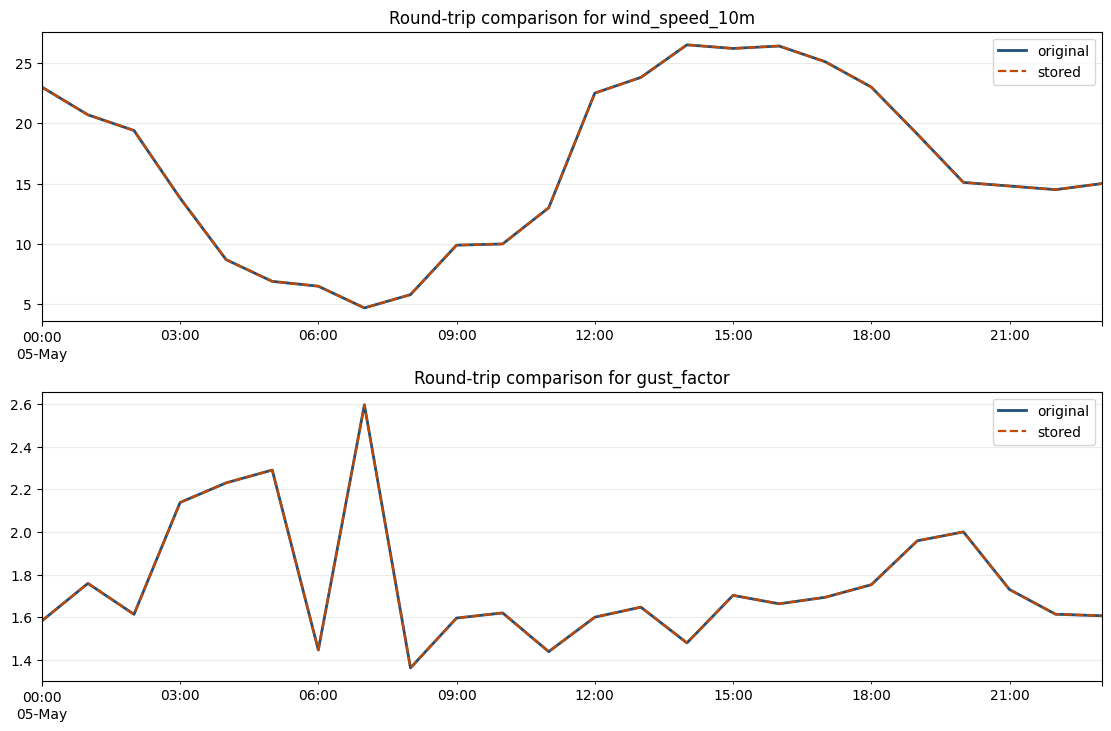

In [11]:
roundtrip_plot_columns = [
    column
    for column in ["wind_speed_10m", "gust_factor"]
    if column in feature_df.columns and column in stored_df.columns
]

fig, axes = plt.subplots(
    len(roundtrip_plot_columns),
    1,
    figsize=(11, 3.6 * len(roundtrip_plot_columns)),
    constrained_layout=True,
    squeeze=False,
)

for axis, column in zip(axes.flatten(), roundtrip_plot_columns, strict=False):
    feature_df[column].head(24).plot(
        ax=axis, color="#1f4e79", linewidth=2.0, label="original"
    )
    stored_df[column].head(24).plot(
        ax=axis, color="#c44900", linewidth=1.6, linestyle="--", label="stored"
    )
    axis.set_title(f"Round-trip comparison for {column}")
    axis.set_xlabel("")
    axis.grid(alpha=0.25)
    axis.legend()

plt.show()

### Step 6 Review Summary

This step is sound if the storage adapter behaves like a persistence layer rather than a second feature-engineering stage.

- The important contract is round-trip fidelity: the stored rows should come back with the same curated feature schema, index semantics, and numeric values that the validation step approved.
- Local, S3-compatible, and BigQuery backends may need different write-time metadata internally, but downstream readers should restore the same feature frame shape instead of leaking backend-specific columns.
- A storage step like this is structural, not semantic. It proves persistence and retrieval consistency, but it does not change whether the feature values themselves are good for prediction.
- For this review, a clean result means no missing or extra columns after read, matching index behavior, zero numeric drift across shared columns, and preserved time structure for later Feast projection.
- Validation should already have passed before this step runs, so storage is operating on an approved curated frame rather than compensating for upstream quality issues.
- The hardened cloud behavior matters here too: BigQuery writes are defined as logical slice replacement for one `spot_id + dataset_name` pair, so reruns do not silently accumulate duplicate curated rows for the same slice.
- Within the scope of this storage-contract review, the necessary adjustment has already been made: backend-specific metadata may exist in storage, but the read path now restores the same curated feature frame contract for downstream consumers.

The remaining storage questions are operational pipeline concerns rather than blockers for this storage-contract review.
They matter once the system runs as a recurring multi-spot job, but they do not change the correctness of this one-spot persistence round-trip check.

The notebook is now a convenience client rather than the monitoring source.
The actual feature pipeline writes a persisted run summary at the pipeline surface, and the next cell reads that summary when it is available for this dataset.
That persisted summary now also carries the source-unit contract: raw wind features remain in km/h, while downstream rideability thresholds stay in knots and are converted later at scoring time instead of changing the stored feature frame.

## 7. Build the Feast Offline Frame

This step validates the actual Feast preparation helpers by reading stored curated rows and reshaping them into
the offline frame and entity rows used for historical retrieval.

In [43]:
import importlib

from foehncast.monitoring import pipeline_metrics as pipeline_metrics_module

pipeline_metrics = importlib.reload(pipeline_metrics_module)
feature_pipeline_stage_overview = pipeline_metrics.feature_pipeline_stage_overview
feature_pipeline_summary_path = pipeline_metrics.feature_pipeline_summary_path
read_feature_pipeline_run_summary = pipeline_metrics.read_feature_pipeline_run_summary

summary_path = feature_pipeline_summary_path(dataset=dataset)

try:
    pipeline_run_summary = read_feature_pipeline_run_summary(dataset=dataset)
except FileNotFoundError:
    print(
        "No persisted feature-pipeline summary found for "
        f"{dataset!r}. Run run_feature_pipeline(dataset=dataset) or "
        "run_feature_pipeline_job(dataset=dataset) first."
    )
else:
    print(f"Summary path: {summary_path}")
    print(f"Run status: {pipeline_run_summary['run_status']}")
    print(
        "Stored spots: "
        f"{pipeline_run_summary['stored_spot_count']} / "
        f"{pipeline_run_summary['expected_spot_count']}"
    )
    spot_overview = feature_pipeline_stage_overview(pipeline_run_summary).set_index(
        "spot_id"
    )
    display(spot_overview)

    unit_contract_columns = [
        "wind_speed_10m_unit",
        "wind_gusts_10m_unit",
        "source_unit_contract_confirmed",
    ]
    available_unit_columns = [
        column for column in unit_contract_columns if column in spot_overview.columns
    ]

    if available_unit_columns:
        display(spot_overview[available_unit_columns])
        print(
            "Source-unit contract confirmed across displayed spots:",
            bool(spot_overview["source_unit_contract_confirmed"].all()),
        )
    else:
        print(
            "This persisted summary predates the explicit source-unit fields. "
            "Rerun the feature pipeline for this dataset to refresh the artifact."
        )

Summary path: /Users/jvr/github/HSLU/MLOPS/foehncast/airflow/reports/feature-pipeline-notebook_eval-latest.json
Run status: succeeded
Stored spots: 6 / 6


,status,error,ingest_rows,wind_speed_10m_unit,wind_gusts_10m_unit,source_unit_contract_confirmed,engineered_rows,engineered_new_columns,validation_passed,range_violation_count,stored_rows,max_numeric_abs_delta,time_basis_preserved,feast_projection_ready,event_timestamp_source
spot_id,,,,,,,,,,,,,,,
silvaplana,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index
urnersee,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index
neuchatel,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index
bodensee,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index
walensee,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index
thunersee,stored,None,168,km/h,km/h,True,168,7,True,0,168,0.0,True,True,datetime_index


,wind_speed_10m_unit,wind_gusts_10m_unit,source_unit_contract_confirmed
spot_id,,,
silvaplana,km/h,km/h,True
urnersee,km/h,km/h,True
neuchatel,km/h,km/h,True
bodensee,km/h,km/h,True
walensee,km/h,km/h,True
thunersee,km/h,km/h,True


Source-unit contract confirmed across displayed spots: True


### Step 7 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 7 Component Diagram

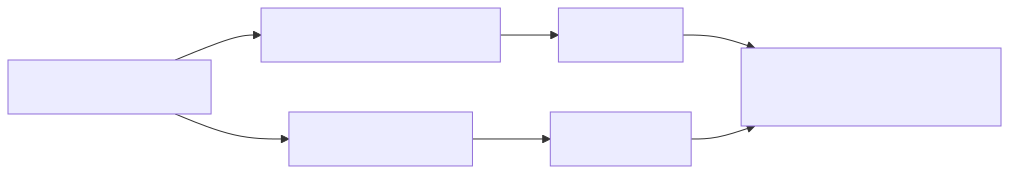

In [22]:
render_mermaid(
    """
    flowchart LR
        A[Stored curated rows] --> B[build_offline_store_frame]
        A --> C[build_entity_rows]
        B --> D[offline_df]
        C --> E[entity_rows]
        D --> F[Feast historical retrieval inputs]
        E --> F
    """,
    title="Step 7 Component Diagram",
)

In [12]:
offline_df = build_offline_store_frame(dataset=dataset)
entity_rows = build_entity_rows(dataset=dataset)

print(f"Offline frame shape: {offline_df.shape}")
print(f"Entity row shape: {entity_rows.shape}")
print(f"Offline columns ({len(offline_df.columns)}): {offline_df.columns.tolist()}")
display(offline_df.head())
display(entity_rows.head())

Offline frame shape: (168, 22)
Entity row shape: (168, 2)
Offline columns (22): ['event_timestamp', 'wind_speed_10m', 'wind_speed_80m', 'wind_speed_120m', 'wind_direction_10m', 'wind_direction_80m', 'wind_gusts_10m', 'temperature_2m', 'precipitation', 'relative_humidity_2m', 'cloud_cover', 'pressure_msl', 'cape', 'lifted_index', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_year_sin', 'day_of_year_cos', 'wind_steadiness', 'gust_factor', 'shore_alignment', 'spot_id']


,event_timestamp,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_direction_10m,wind_direction_80m,wind_gusts_10m,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,pressure_msl,cape,lifted_index,hour_of_day_sin,hour_of_day_cos,day_of_year_sin,day_of_year_cos,wind_steadiness,gust_factor,shore_alignment,spot_id
0,2026-05-04 22:00:00+00:00,23.0,30.4,31.0,256,251,36.4,5.8,0.0,75,75,1016.8,0.0,6.4,0.000000,1.000000,0.845249,-0.534373,0.000000,1.582609,0.857167,silvaplana
1,2026-05-04 23:00:00+00:00,20.7,27.4,28.3,253,251,36.4,5.4,0.0,73,81,1016.8,0.0,6.9,0.258819,0.965926,0.845249,-0.534373,0.052632,1.758454,0.882948,silvaplana
2,2026-05-05 00:00:00+00:00,19.4,25.5,26.4,260,254,31.3,5.1,0.0,70,44,1016.4,0.0,8.9,0.500000,0.866025,0.845249,-0.534373,0.070767,1.613402,0.819152,silvaplana
3,2026-05-05 01:00:00+00:00,13.8,19.4,20.5,261,255,29.5,4.9,0.0,69,25,1015.4,0.0,8.7,0.707107,0.707107,0.845249,-0.534373,0.166625,2.137681,0.809017,silvaplana
4,2026-05-05 02:00:00+00:00,8.7,14.0,15.5,253,247,19.4,4.6,0.0,72,17,1015.1,0.0,10.0,0.866025,0.500000,0.845249,-0.534373,0.312877,2.229885,0.882948,silvaplana


,spot_id,event_timestamp
0,silvaplana,2026-05-04 22:00:00+00:00
1,silvaplana,2026-05-04 23:00:00+00:00
2,silvaplana,2026-05-05 00:00:00+00:00
3,silvaplana,2026-05-05 01:00:00+00:00
4,silvaplana,2026-05-05 02:00:00+00:00


### Step 7 Review Summary

This step is sound if Feast remains a downstream consumer of curated feature rows rather than a second storage or feature-engineering layer.

- `build_offline_store_frame(dataset=...)` and `build_entity_rows(dataset=...)` are the real helpers the local Feast workflow depends on, so this review is validating the same reshaping contract used outside this notebook.
- The important boundary is that Feast consumes stored curated features; it does not reach back into raw ingest or recompute engineering logic.
- The offline frame and entity rows should stay thin, deterministic projections of the stored feature set so local and cloud Feast paths can share the same conceptual contract.

If this boundary stays clean, later README and site documentation can explain Feast as an interface over curated features instead of presenting it as the center of the pipeline.

## 8. Export a Feast-Ready Parquet File

This mirrors the export step behind `scripts/prepare-feast-local.sh`, but keeps the intermediate frame
visible in this design-review artifact so you can inspect the real export contract before applying or materializing the Feast repo.

### Step 8 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

### Step 8 Component Diagram

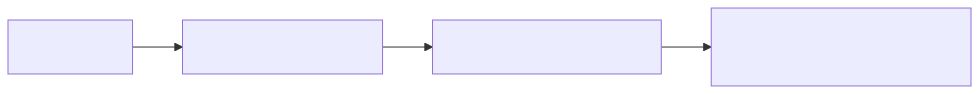

In [23]:
render_mermaid(
    """
    flowchart LR
        A[offline_df] --> B[export_offline_store]
        B --> C[Feast-ready parquet file]
        C --> D[feature_repo and materialization flow]
    """,
    title="Step 8 Component Diagram",
)

In [13]:
exported_path = export_offline_store(dataset=dataset, output_path=feast_export_path)
exported_df = pd.read_parquet(exported_path)

print(f"Exported Feast parquet: {exported_path}")
print(f"Exported shape: {exported_df.shape}")
display(exported_df.head())

Exported Feast parquet: /Users/jvr/github/HSLU/MLOPS/foehncast/data/feast/notebook_eval.parquet
Exported shape: (168, 22)


,event_timestamp,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_direction_10m,wind_direction_80m,wind_gusts_10m,temperature_2m,precipitation,relative_humidity_2m,cloud_cover,pressure_msl,cape,lifted_index,hour_of_day_sin,hour_of_day_cos,day_of_year_sin,day_of_year_cos,wind_steadiness,gust_factor,shore_alignment,spot_id
0,2026-05-04 22:00:00+00:00,23.0,30.4,31.0,256,251,36.4,5.8,0.0,75,75,1016.8,0.0,6.4,0.000000,1.000000,0.845249,-0.534373,0.000000,1.582609,0.857167,silvaplana
1,2026-05-04 23:00:00+00:00,20.7,27.4,28.3,253,251,36.4,5.4,0.0,73,81,1016.8,0.0,6.9,0.258819,0.965926,0.845249,-0.534373,0.052632,1.758454,0.882948,silvaplana
2,2026-05-05 00:00:00+00:00,19.4,25.5,26.4,260,254,31.3,5.1,0.0,70,44,1016.4,0.0,8.9,0.500000,0.866025,0.845249,-0.534373,0.070767,1.613402,0.819152,silvaplana
3,2026-05-05 01:00:00+00:00,13.8,19.4,20.5,261,255,29.5,4.9,0.0,69,25,1015.4,0.0,8.7,0.707107,0.707107,0.845249,-0.534373,0.166625,2.137681,0.809017,silvaplana
4,2026-05-05 02:00:00+00:00,8.7,14.0,15.5,253,247,19.4,4.6,0.0,72,17,1015.1,0.0,10.0,0.866025,0.500000,0.845249,-0.534373,0.312877,2.229885,0.882948,silvaplana


### Step 8 Review Summary

This step is sound if the export helper is a deterministic materialization step rather than another place where feature logic can drift.

- `export_offline_store(...)` should write the same offline frame contract that the Feast repo and preparation script expect, without changing feature semantics on the way out.
- Keeping the parquet artifact inspectable here is useful for documentation because it shows the hand-off boundary between curated feature preparation and Feast materialization.
- The local script remains useful as an operator wrapper, but the real component under validation is the export helper itself.

If this export stays thin and predictable, later README and GitHub Pages documentation can describe the Feast hand-off without duplicating the execution details from the notebook.

## 9. Documentation Handoff and Next Steps

This closing section turns the notebook into a documentation bridge rather than a permanent public artifact.
The notebook should remain the detailed review evidence, while README and GitHub Pages content should extract only the validated architecture, contracts, and operator flow.

### Documentation Extraction Outline

| Target | Extract from this review | Leave in the notebook |
| --- | --- | --- |
| README | short pipeline overview, stage responsibilities, local-first storage baseline, Feast boundary, and main operator entrypoints | exploratory commentary, intermediate inspection tables, plots, and run-specific outputs |
| GitHub Pages | architecture diagrams, storage and cloud target design, curated feature contract, validation boundary, and Feast hand-off | per-run dataset snapshots, local execution noise, and ad hoc inspection cells |
| Notebook | full evidence trail, helper execution, intermediate frames, and detailed design reasoning | not applicable |

### Stable Sections To Reuse

- Step 1 for configuration scope, Feast boundary, typed loading direction, and preprocessing rationale.
- Step 2 for storage roles, raw-vs-curated separation, and local-versus-cloud architecture.
- Steps 3 to 6 for ingest, engineering, validation, and storage round-trip contracts.
- Steps 7 and 8 for Feast preparation, export boundaries, and operator hand-off points.

### Step 9 Component Diagram

Run the next cell to render the diagram from the notebook kernel.

Once this one-spot review looks correct, the batch helper `run_feature_pipeline(dataset=...)` applies
the same ingest -> engineer -> validate -> store loop across all configured spots.

Feature-preprocessing follow-up stays outside this review: the current tree-based model path does not need a global scaler, so downstream work should focus on circular wind-direction features, gustiness stabilization, and aligning engineered-feature declarations with the implemented pipeline.

### Operator Next Steps

If you want to wire this isolated review dataset into the local Feast repo, the next operator steps are:

- `uv sync --group feast`
- `./scripts/prepare-feast-local.sh notebook_eval`
- `cd feature_repo && uv run --group feast feast materialize-incremental "$(date -u +"%Y-%m-%dT%H:%M:%S")"`

### Step 9 Component Diagram

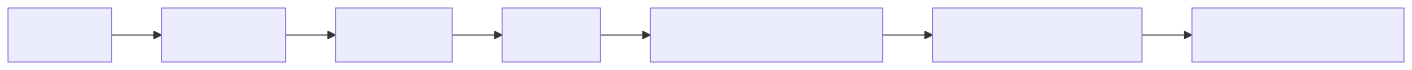

In [17]:
render_mermaid(
    """
    flowchart LR
        A[Ingest] --> B[Engineer]
        B --> C[Validate]
        C --> D[Store]
        D --> E[Build Feast offline frame]
        E --> F[Export Feast parquet]
        F --> G[Materialize and serve]
    """,
    title="Step 9 Component Diagram",
)